# Semantic segmentation on Oxford-IIIT Pets: FCN to U-Net

Pixel-wise segmentation of pet photos into three classes (pet / background / border) in PyTorch. The notebook starts
from a fully convolutional baseline and improves it step by step: U-Net, deeper U-Net, mIoU / Dice metrics, class
weights, BatchNorm.

> **About the comments.** The explanatory comments and section headings in this notebook were written with the help of
> Claude (an AI assistant by Anthropic) to make it easier to navigate. The models, experiments and code are the author's.

## Contents and results

All numbers below are **validation** metrics at the last epoch (see the notes).

| # | Model | Valid loss | Accuracy / mIoU | Dice (see note 2) |
|---|-------|-----------|-----------------|-------------------|
| 2 | FCN baseline | 0.6812 | acc 0.5286 | -- |
| 3 | U-Net, 2 levels | 0.3485 | acc 0.7825 | -- |
| 4 | Deeper U-Net, 4 levels | 0.2996 | mIoU 0.7063 | 0.5442 |
| 5 | + computed class weights | 0.3708 | mIoU 0.6925 | 0.5570 |
| 6 | + BatchNorm, fixed class weights | 0.3032 | mIoU 0.7379 | 0.5774 |

**Notes.**
1. The cells titled "Evaluate ... on the test set" accumulate test metrics but print the last *validation* numbers
   (and the last training loss), so no genuine test-set score is recorded in this notebook.
2. `Dice (excl. BG)` uses `ignore_index=0`, but in the mask encoding used here class 0 is *pet* and background is
   class 1, so this Dice actually excludes the pet class.
3. The cells were executed out of order across several kernel sessions, and `random_split` is not seeded. The
   resolution / batch size that produced the stored outputs of section 6 cannot be verified from the file alone (the
   256x256 dataset cells sit before it in the notebook). Re-running top to bottom will give somewhat different numbers.
4. All training cells expect a CUDA GPU.

In [ ]:
# Imports
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchmetrics.classification import MulticlassAccuracy
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms.functional as F
import random
import numpy as np
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassF1Score

## 0. Setup and data

Expected folder layout (Oxford-IIIT Pet dataset, not included in this repository):

```
data/oxford_pets/
  Pets/*.jpg     # images
  Mask/*.png     # trimap masks (1 = pet, 2 = background, 3 = border)
```

Point `DATA_ROOT` in the next cell to your copy.

In [ ]:
device = 'cuda'
# Oxford-IIIT Pet dataset: JPEG images and trimap PNG masks, each in a flat folder
DATA_ROOT = Path('data/oxford_pets')
IMAGE_PATH = DATA_ROOT / 'Pets'   # images/*.jpg
MASK_PATH = DATA_ROOT / 'Mask'    # annotations/trimaps/*.png


In [ ]:
# Sanity check: number of entries in the images and masks folders (they should match)
total_objects = len(list(IMAGE_PATH.rglob("*")))
print(f"Entries in images folder: {total_objects}")


total_objects = len(list(MASK_PATH.rglob("*")))
print(f"Entries in masks folder: {total_objects}")


Entries in images folder: 7390
Entries in masks folder: 7390


### Clean-up: stray .mat files

In [ ]:
import os

# Oxford-IIIT Pet ships a few .mat files inside the images folder; find them
mat_files = [f for f in os.listdir(IMAGE_PATH) if f.endswith(".mat")]
print(f"Found {len(mat_files)} .mat files")
print(mat_files[:5])   # first 5, to make sure these are the right files


Found 0 .mat files
[]


In [ ]:
# One-off cleanup: delete the stray .mat files so that images and masks pair up one-to-one
# (0 were left when this was run). This permanently deletes files -- run it only on your own copy of the data.
for f in mat_files:
    os.remove(os.path.join(IMAGE_PATH, f))

print("Deleted:", len(mat_files))


Deleted: 0


In [ ]:
# Sanity check: number of entries in the images and masks folders (they should match)
total_objects = len(list(IMAGE_PATH.rglob("*")))
print(f"Entries in images folder: {total_objects}")


total_objects = len(list(MASK_PATH.rglob("*")))
print(f"Entries in masks folder: {total_objects}")


Entries in images folder: 7390
Entries in masks folder: 7390


### Image-mask pairs

In [ ]:
# Pair every image with its mask. This relies on both folders listing files in the same (alphabetical) order:
# file names match one-to-one (e.g. Abyssinian_1.jpg <-> Abyssinian_1.png).
# image path -> mask path
dataset_dict = {i: m for i, m in zip(list(IMAGE_PATH.rglob("*")), list(MASK_PATH.rglob("*")))}


    


## 1. Dataset with paired augmentation (128x128)

Image and mask receive the same geometric transforms (flip, rotation, crop); photometric transforms touch only the
image. Masks are resized with nearest-neighbour interpolation so that class ids stay intact. After shifting the
trimap the classes are: 0 = pet, 1 = background, 2 = border.

In [ ]:
# Returns (image, mask) pairs; `train=True` switches on the paired augmentations
from PIL import Image
from torch.utils.data import Dataset

class PetSegDataset(Dataset):
    def __init__(self, dataset_dict, train=True):
        self.pairs = list(dataset_dict.items())
        self.train = train   # augmentations only for train, never for valid / test

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # -- Geometry: the SAME random parameters are applied to image and mask --
        image = F.resize(image, (128, 128))
        mask = F.resize(mask, (128, 128), interpolation=transforms.InterpolationMode.NEAREST)  # NEAREST keeps mask values valid class ids (no interpolation between classes)

        if self.train:
            if random.random() > 0.5:                       # horizontal flip
                image = F.hflip(image)
                mask = F.hflip(mask)

            angle = random.uniform(-15, 15)                  # ONE angle for both
            image = F.rotate(image, angle)
            mask = F.rotate(mask, angle, fill=2)              # fill=2 is 'background' in the raw trimap, so the corners created by rotation are labelled background

            i, j, h, w = transforms.RandomCrop.get_params(image, output_size=(112, 112))
            image = F.crop(image, i, j, h, w)                 # the SAME crop coordinates for both
            mask = F.crop(mask, i, j, h, w)
            image = F.resize(image, (128, 128))
            mask = F.resize(mask, (128, 128), interpolation=transforms.InterpolationMode.NEAREST)

            # -- Photometric: image ONLY, the mask is left untouched --
            image = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)(image)

        image = F.to_tensor(image)
        # Raw trimap values: 1 = pet, 2 = background, 3 = border.
        # Shift to 0-based class ids: 0 = pet, 1 = background, 2 = border
        mask = (F.pil_to_tensor(mask).long() - 1).squeeze(0)

        return image, mask

In [ ]:
full_dataset_train = PetSegDataset(dataset_dict, train=True)    # with augmentation
full_dataset_plain = PetSegDataset(dataset_dict, train=False)    # without augmentation

# Split the indices once (70 / 15 / 15, no fixed seed), then wrap the augmented / plain dataset versions with the same indices
train_ds, valid_ds, test_ds = torch.utils.data.random_split(
    range(len(full_dataset_train)), [0.7, 0.15, 0.15]
)

# NOTE: random_split is not seeded, so the split (and therefore the results) differ between runs
from torch.utils.data import Subset
train_ds = Subset(full_dataset_train, train_ds.indices)   # train -- WITH augmentation
valid_ds = Subset(full_dataset_plain, valid_ds.indices)     # valid -- WITHOUT augmentation
test_ds  = Subset(full_dataset_plain, test_ds.indices)       # test  -- WITHOUT augmentation

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

## 2. Baseline: fully convolutional network (FCN)

Seven conv + pool stages, then a single transposed convolution upsamples the 1x1 map back to 128x128.
A weak baseline: valid loss 0.6812, accuracy 0.5286.

In [ ]:
# Baseline FCN: 7 x (Conv -> ReLU -> MaxPool) shrink 128x128 to 1x1, a conv classifier predicts 3 classes,
# then one large transposed convolution (kernel = stride = 128) upsamples back to 128x128
class SimpleFCN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                     nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                     nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                     nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                     nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                     nn.Conv2d(in_channels=256, out_channels=328, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                     nn.Conv2d(in_channels=328, out_channels=656, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        
        self.classifier = nn.Conv2d(in_channels=656, out_channels=num_classes, kernel_size=3, padding=1)

        self.upsample = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=128, stride=128) # output size = input size * stride when stride == kernel_size

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return self.upsample(x)

In [ ]:
# Train the baseline FCN with cross-entropy loss (mask = class id per pixel)
# Model, loss, optimizer and metric live on the GPU (a CUDA device is required)
model = SimpleFCN().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3, weight_decay=1e-4)
accuracy = MulticlassAccuracy(num_classes=3).to('cuda')
# NOTE: in the original run `epochs` was defined below this line and was picked up from an earlier kernel
# session; it is moved up here so the notebook runs from top to bottom.
# Number of passes over the training set
epochs = 30
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    
    eta_min=1e-5     
)

# Per-epoch history used for the loss curves
train_loss = []
valid_loss = []


# One epoch = a training pass followed by a validation pass
for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    # Training mode: dropout active, BatchNorm uses batch statistics
    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        # Forward pass
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        # Backward pass and parameter update
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    # Evaluation mode: no dropout, BatchNorm uses running statistics
    model.eval()

    # No gradients are needed for validation
    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            # Accumulate accuracy over all validation batches
            accuracy.update(valid_predictions, valid_labels)

    # Average the losses over batches
    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    # Accuracy over the whole validation set for this epoch
    # (torchmetrics MulticlassAccuracy, macro-averaged over the 3 classes)
    acc = accuracy.compute()

    
    print(f'Epoch: {epoch+1} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f}')

    # Reset the metric for the next epoch
    accuracy.reset()
    # Cosine schedule: step once per epoch
    scheduler.step()

Epoch: 1 | Train loss: 0.7693 | Valid loss: 0.7498 | Accuracy: 0.4941
Epoch: 2 | Train loss: 0.7459 | Valid loss: 0.7409 | Accuracy: 0.4959
Epoch: 3 | Train loss: 0.7444 | Valid loss: 0.7390 | Accuracy: 0.4936
Epoch: 4 | Train loss: 0.7439 | Valid loss: 0.7403 | Accuracy: 0.4928
Epoch: 5 | Train loss: 0.7456 | Valid loss: 0.7397 | Accuracy: 0.4912
Epoch: 6 | Train loss: 0.7445 | Valid loss: 0.7405 | Accuracy: 0.4900
Epoch: 7 | Train loss: 0.7431 | Valid loss: 0.7392 | Accuracy: 0.4854
Epoch: 8 | Train loss: 0.7416 | Valid loss: 0.7466 | Accuracy: 0.4875
Epoch: 9 | Train loss: 0.7422 | Valid loss: 0.7413 | Accuracy: 0.4974
Epoch: 10 | Train loss: 0.7419 | Valid loss: 0.7380 | Accuracy: 0.4894
Epoch: 11 | Train loss: 0.7405 | Valid loss: 0.7347 | Accuracy: 0.4932
Epoch: 12 | Train loss: 0.7383 | Valid loss: 0.7437 | Accuracy: 0.4902
Epoch: 13 | Train loss: 0.7381 | Valid loss: 0.7345 | Accuracy: 0.4908
Epoch: 14 | Train loss: 0.7365 | Valid loss: 0.7440 | Accuracy: 0.5021
Epoch: 15 | Tra

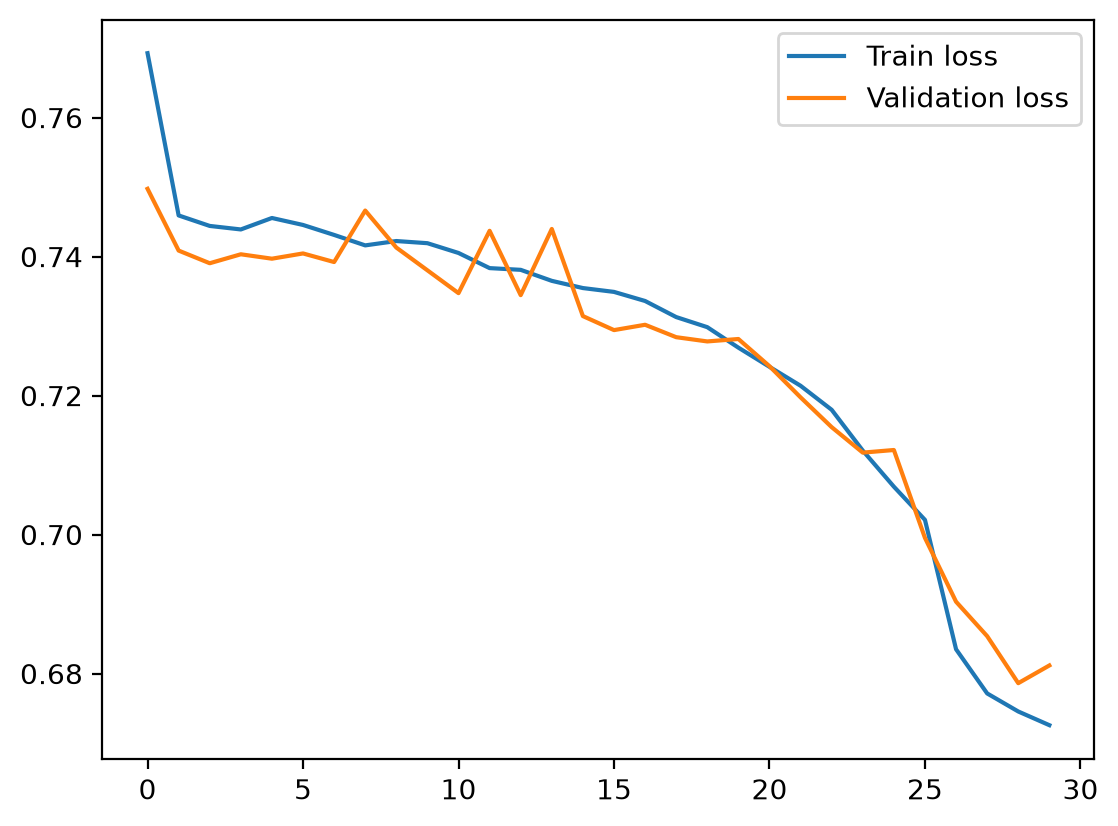

In [ ]:
# Loss curves
import numpy as np
plt.figure(dpi=200)
plt.plot(np.arange(0, 30), train_loss, label='Train loss')
plt.plot(np.arange(0, 30), valid_loss, label='Validation loss')
plt.legend()
plt.show()

## 3. U-Net (two encoder levels)

Skip connections concatenate encoder features into the decoder. Valid loss 0.3485, accuracy 0.7825.


In [ ]:
# U-Net with two encoder levels: enc1 (64) -> enc2 (128) -> bottleneck (256), mirrored decoder with skip connections
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, padding=1), nn.ReLU(),
                                   nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1), nn.ReLU())
    
    def forward(self, x):
        return self.block(x)


class SimpleUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.enc1 = UNetBlock(3, 64)
        self.enc2 = UNetBlock(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = UNetBlock(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = UNetBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = UNetBlock(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d2 = self.up2(b)

        # concatenate encoder features (skip connection)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.final(d1)

In [ ]:
# Same loop as the FCN run, with the two-level U-Net.
model = SimpleUNet().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3, weight_decay=1e-4)
accuracy = MulticlassAccuracy(num_classes=3).to('cuda')
# NOTE: in the original run `epochs` was defined below this line and was picked up from an earlier kernel
# session; it is moved up here so the notebook runs from top to bottom.
epochs = 30
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    # One full cosine cycle over all epochs
    eta_min=1e-5     # Minimum learning rate at the end
)

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()

    
    print(f'Epoch: {epoch+1} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f}')

    accuracy.reset()
    scheduler.step()

Epoch: 1 | Train loss: 0.7675 | Valid loss: 0.6902 | Accuracy: 0.5708
Epoch: 2 | Train loss: 0.6183 | Valid loss: 0.5912 | Accuracy: 0.6276
Epoch: 3 | Train loss: 0.5741 | Valid loss: 0.5310 | Accuracy: 0.6541
Epoch: 4 | Train loss: 0.5356 | Valid loss: 0.5515 | Accuracy: 0.6837
Epoch: 5 | Train loss: 0.5223 | Valid loss: 0.5276 | Accuracy: 0.6777
Epoch: 6 | Train loss: 0.4884 | Valid loss: 0.4740 | Accuracy: 0.7103
Epoch: 7 | Train loss: 0.4765 | Valid loss: 0.4631 | Accuracy: 0.7401
Epoch: 8 | Train loss: 0.4581 | Valid loss: 0.4345 | Accuracy: 0.7360
Epoch: 9 | Train loss: 0.4406 | Valid loss: 0.4271 | Accuracy: 0.7273
Epoch: 10 | Train loss: 0.4306 | Valid loss: 0.4195 | Accuracy: 0.7409
Epoch: 11 | Train loss: 0.4215 | Valid loss: 0.4517 | Accuracy: 0.7007
Epoch: 12 | Train loss: 0.4112 | Valid loss: 0.4020 | Accuracy: 0.7460
Epoch: 13 | Train loss: 0.4039 | Valid loss: 0.3957 | Accuracy: 0.7567
Epoch: 14 | Train loss: 0.3915 | Valid loss: 0.4024 | Accuracy: 0.7484
Epoch: 15 | Tra

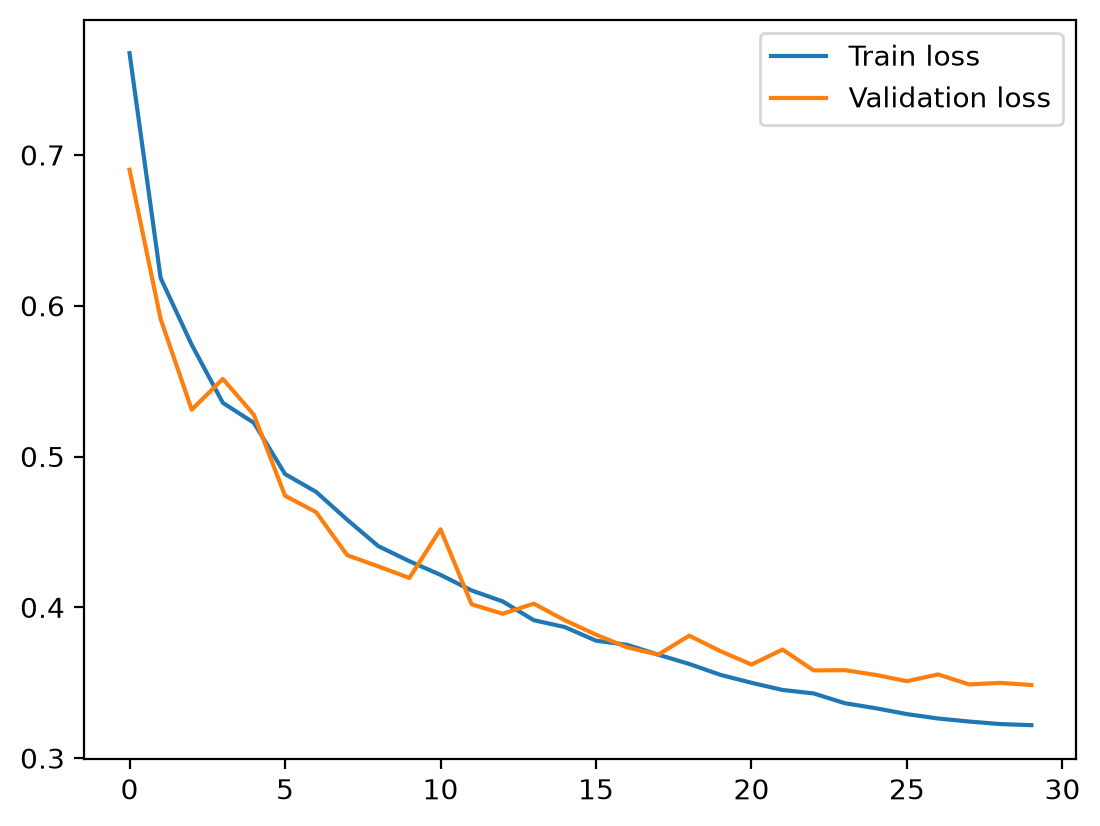

In [ ]:
# Loss curves
plt.figure(dpi=200)
plt.plot(np.arange(0, 30), train_loss, label='Train loss')
plt.plot(np.arange(0, 30), valid_loss, label='Validation loss')
plt.legend()
plt.show()

## 4. Deeper U-Net (four encoder levels) with mIoU and Dice

Two more levels (up to 1024 channels in the bottleneck); mIoU and Dice become the main metrics.
At epoch 30 on the validation set: loss 0.2996, mIoU 0.7063, Dice 0.5442.

In [ ]:
# Deeper U-Net: four encoder levels, bottleneck with 1024 channels
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1), nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class DeeperUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Encoder -- four levels (64-128-256-512 channels) instead of two
        self.enc1 = UNetBlock(3, 64)
        self.enc2 = UNetBlock(64, 128)
        self.enc3 = UNetBlock(128, 256) 
        self.enc4 = UNetBlock(256, 512)       
        self.pool = nn.MaxPool2d(2)             

        self.bottleneck = UNetBlock(512, 1024)   # was (128, 256) in the two-level U-Net, now deeper

        # Decoder -- symmetric, four levels
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = UNetBlock(1024, 512)          

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = UNetBlock(512, 256)           

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = UNetBlock(256, 128)             

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = UNetBlock(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))              
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))  

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

In [ ]:
# Train the deeper U-Net with cross-entropy; mIoU and Dice are tracked on the validation set.
import torch
import torch.nn as nn
# Segmentation metrics
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassF1Score

epochs = 30
num_classes = 3

model = DeeperUNet().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3, weight_decay=1e-5)

# Create the mIoU and Dice metrics on the GPU
# mIoU = mean Jaccard index over the classes
miou_metric = MulticlassJaccardIndex(num_classes=num_classes).to('cuda')
# Dice (macro F1) with ignore_index=0. NOTE: in this encoding class 0 is 'pet', not background
# (0 = pet, 1 = background, 2 = border), so this actually ignores the pet class.
dice_metric = MulticlassF1Score(num_classes=num_classes, average="macro", ignore_index=0).to('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    
    eta_min=1e-5     
)

train_loss = []
valid_loss = []

for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        
        train_sum_loss += tr_loss.item()

    model.eval()
    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            
            # Update the validation metrics
            miou_metric.update(valid_predictions, valid_labels)
            dice_metric.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    
    # Final values for this epoch
    epoch_miou = miou_metric.compute()
    epoch_dice = dice_metric.compute()
    
    print(f'Epoch: {epoch+1:02d} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Valid Loss: {avg_val_loss:.4f} | '
          f'mIoU: {epoch_miou:.4f} | '
          f'Dice (excl. BG): {epoch_dice:.4f}')

    # Reset the metrics before the next epoch
    miou_metric.reset()
    dice_metric.reset()
    
    scheduler.step()


Epoch: 01 | Train Loss: 0.9168 | Valid Loss: 0.8148 | mIoU: 0.3275 | Dice (excl. BG): 0.2423
Epoch: 02 | Train Loss: 0.7963 | Valid Loss: 0.6813 | mIoU: 0.4443 | Dice (excl. BG): 0.3694
Epoch: 03 | Train Loss: 0.7234 | Valid Loss: 0.6612 | mIoU: 0.4913 | Dice (excl. BG): 0.4236
Epoch: 04 | Train Loss: 0.6724 | Valid Loss: 0.5906 | mIoU: 0.5337 | Dice (excl. BG): 0.4563
Epoch: 05 | Train Loss: 0.6195 | Valid Loss: 0.4979 | mIoU: 0.5726 | Dice (excl. BG): 0.4884
Epoch: 06 | Train Loss: 0.5751 | Valid Loss: 0.4829 | mIoU: 0.5810 | Dice (excl. BG): 0.4722
Epoch: 07 | Train Loss: 0.5265 | Valid Loss: 0.4257 | mIoU: 0.6239 | Dice (excl. BG): 0.5114
Epoch: 08 | Train Loss: 0.4966 | Valid Loss: 0.4257 | mIoU: 0.6140 | Dice (excl. BG): 0.4923
Epoch: 09 | Train Loss: 0.4764 | Valid Loss: 0.4009 | mIoU: 0.6438 | Dice (excl. BG): 0.5185
Epoch: 10 | Train Loss: 0.4560 | Valid Loss: 0.3810 | mIoU: 0.6484 | Dice (excl. BG): 0.5041
Epoch: 11 | Train Loss: 0.4388 | Valid Loss: 0.3853 | mIoU: 0.6482 | D

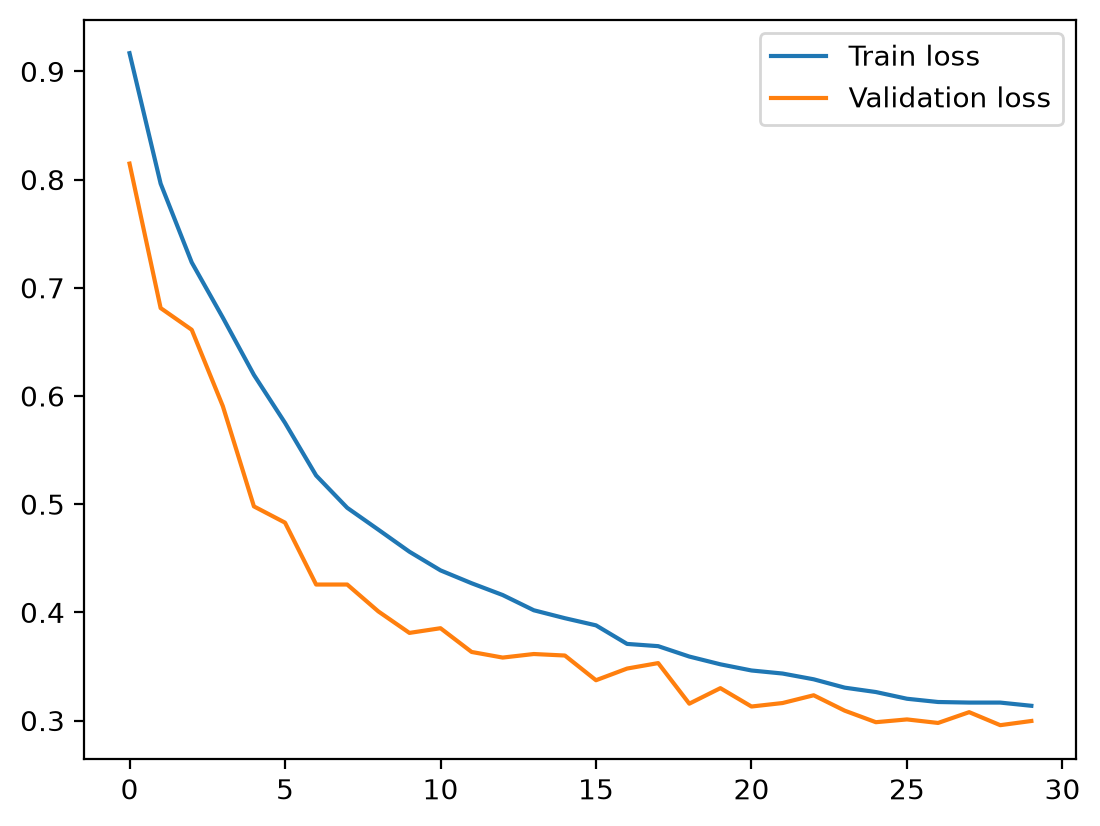

In [ ]:
# Loss curves
plt.figure(dpi=200)
plt.plot(np.arange(0, 30), train_loss, label='Train loss')
plt.plot(np.arange(0, 30), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# NOTE: this cell accumulates test-set metrics but never calls .compute() on them. The printed line reuses
# avg_train_loss (last training epoch) and epoch_miou / epoch_dice (last VALIDATION epoch), so the numbers
# below are validation results, not test results.
# Evaluate the trained model on the test set
test_sum_loss = 0
preds = []
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        miou_metric.update(test_predictions, test_labels)
        dice_metric.update(test_predictions, test_labels)
        preds.append(test_predictions)

avg_test_loss = test_sum_loss/len(test_loader)
print(    f'Test Loss: {avg_train_loss:.4f} | '
          f'mIoU: {epoch_miou:.4f} | '
          f'Dice (excl. BG): {epoch_dice:.4f}')

dice_metric.reset()
miou_metric.reset()       

Test Loss: 0.3136 | mIoU: 0.7063 | Dice (excl. BG): 0.5442


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.1668305..15.862088].


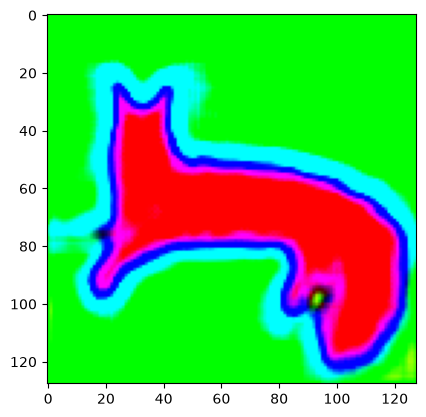

In [ ]:
# NOTE: raw logits shown as an RGB image (imshow clips the values, hence the warning); see the argmax view at the end for a readable mask.
img = preds[5][13].cpu().numpy().transpose(1, 2, 0) 
imgplot = plt.imshow(img)

## 5. Class weights

Inverse-frequency weights computed from the training masks counter the class imbalance (the border class is rare).
Validation: loss 0.3708, mIoU 0.6925, Dice 0.5570.

In [ ]:
# Inverse-frequency class weights computed from the training masks (rare class -> larger weight)
import torch

class_counts = torch.zeros(3)
for _, masks in train_loader:
    for c in range(3):
        class_counts[c] += (masks == c).sum()

freq = class_counts / class_counts.sum()
weights = (1.0 / freq)
weights = weights / weights.sum() * 3   # normalize so that the mean weight is ~1

print("Class weights:", weights)


Class weights: tensor([0.6733, 0.4877, 1.8390])


In [ ]:
# Train the deeper U-Net with the computed class weights in the cross-entropy loss.
epochs = 30
num_classes = 3

model = DeeperUNet().to('cuda')
loss_fn = nn.CrossEntropyLoss(weight=weights.to('cuda')).to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

# Create the mIoU and Dice metrics on the GPU
# mIoU = mean Jaccard index over the classes
miou_metric = MulticlassJaccardIndex(num_classes=num_classes).to('cuda')
# Dice (macro F1) with ignore_index=0. NOTE: in this encoding class 0 is 'pet', not background
# (0 = pet, 1 = background, 2 = border), so this actually ignores the pet class.
dice_metric = MulticlassF1Score(num_classes=num_classes, average="macro", ignore_index=0).to('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    
    eta_min=1e-5     
)

train_loss = []
valid_loss = []

for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        
        train_sum_loss += tr_loss.item()

    model.eval()
    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            
            # Update the validation metrics
            miou_metric.update(valid_predictions, valid_labels)
            dice_metric.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    
    # Final values for this epoch
    epoch_miou = miou_metric.compute()
    epoch_dice = dice_metric.compute()
    
    print(f'Epoch: {epoch+1:02d} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Valid Loss: {avg_val_loss:.4f} | '
          f'mIoU: {epoch_miou:.4f} | '
          f'Dice (excl. BG): {epoch_dice:.4f}')

    # Reset the metrics before the next epoch
    miou_metric.reset()
    dice_metric.reset()
    
    scheduler.step()


Epoch: 01 | Train Loss: 1.1039 | Valid Loss: 1.0245 | mIoU: 0.1942 | Dice (excl. BG): 0.2804
Epoch: 02 | Train Loss: 0.9168 | Valid Loss: 0.8753 | mIoU: 0.3853 | Dice (excl. BG): 0.3642
Epoch: 03 | Train Loss: 0.7908 | Valid Loss: 0.7038 | mIoU: 0.5108 | Dice (excl. BG): 0.4403
Epoch: 04 | Train Loss: 0.7104 | Valid Loss: 0.6792 | mIoU: 0.5377 | Dice (excl. BG): 0.4484
Epoch: 05 | Train Loss: 0.6532 | Valid Loss: 0.5609 | mIoU: 0.5884 | Dice (excl. BG): 0.5052
Epoch: 06 | Train Loss: 0.5983 | Valid Loss: 0.5240 | mIoU: 0.6067 | Dice (excl. BG): 0.5172
Epoch: 07 | Train Loss: 0.5634 | Valid Loss: 0.5042 | mIoU: 0.6120 | Dice (excl. BG): 0.5071
Epoch: 08 | Train Loss: 0.5444 | Valid Loss: 0.5008 | mIoU: 0.6272 | Dice (excl. BG): 0.5391
Epoch: 09 | Train Loss: 0.5164 | Valid Loss: 0.4592 | mIoU: 0.6500 | Dice (excl. BG): 0.5290
Epoch: 10 | Train Loss: 0.5039 | Valid Loss: 0.4551 | mIoU: 0.6351 | Dice (excl. BG): 0.5224
Epoch: 11 | Train Loss: 0.4900 | Valid Loss: 0.4492 | mIoU: 0.6363 | D

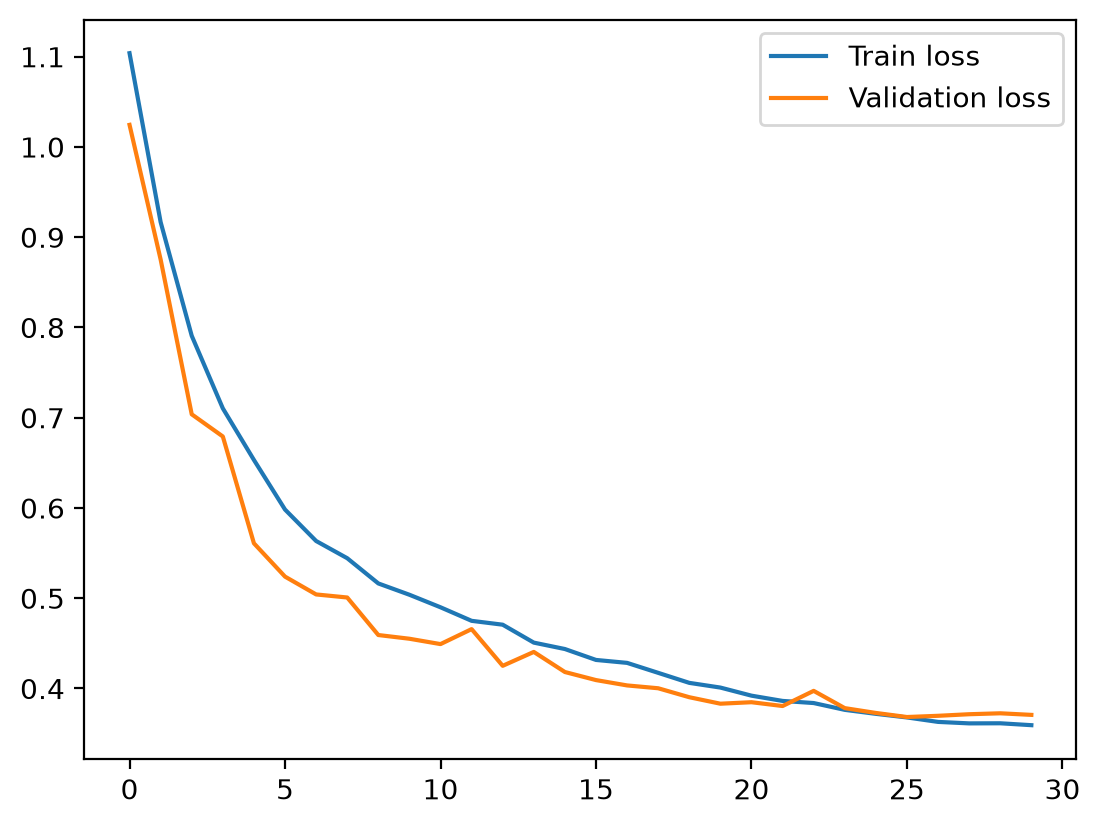

In [ ]:
# Loss curves
plt.figure(dpi=200)
plt.plot(np.arange(0, 30), train_loss, label='Train loss')
plt.plot(np.arange(0, 30), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# NOTE: this cell accumulates test-set metrics but never calls .compute() on them. The printed line reuses
# avg_train_loss (last training epoch) and epoch_miou / epoch_dice (last VALIDATION epoch), so the numbers
# below are validation results, not test results.
# Evaluate the trained model on the test set
test_sum_loss = 0
preds = []
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        miou_metric.update(test_predictions, test_labels)
        dice_metric.update(test_predictions, test_labels)
        preds.append(test_predictions)

avg_test_loss = test_sum_loss/len(test_loader)
print(    f'Test Loss: {avg_train_loss:.4f} | '
          f'mIoU: {epoch_miou:.4f} | '
          f'Dice (excl. BG): {epoch_dice:.4f}')

dice_metric.reset()
miou_metric.reset()       

Test Loss: 0.3594 | mIoU: 0.6925 | Dice (excl. BG): 0.5570


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.3123364..10.183679].


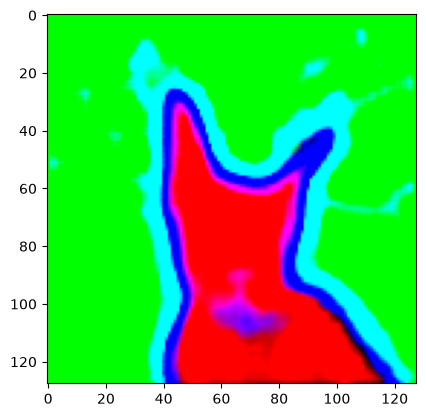

In [ ]:
# NOTE: raw logits shown as an RGB image (imshow clips the values, hence the warning); see the argmax view at the end for a readable mask.
img = preds[5][12].cpu().numpy().transpose(1, 2, 0) 
imgplot = plt.imshow(img)

## 6. BatchNorm U-Net with fixed class weights

The dataset class is redefined for 256x256 inputs (batch size 8), `UNetBlock` gets BatchNorm and the class weights are
fixed by hand. Validation: loss 0.3032, mIoU 0.7379, Dice 0.5774 -- the best result in this notebook.
See note 3 above about which resolution produced the stored outputs.

In [ ]:
# Returns (image, mask) pairs; `train=True` switches on the paired augmentations
class PetSegDataset(Dataset):
    def __init__(self, dataset_dict, train=True):
        self.pairs = list(dataset_dict.items())
        self.train = train   # augmentations only for train, never for valid / test

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # -- Geometry: the SAME random parameters are applied to image and mask --
        image = F.resize(image, (256, 256))
        mask = F.resize(mask, (256, 256), interpolation=transforms.InterpolationMode.NEAREST)  # NEAREST keeps mask values valid class ids (no interpolation between classes)

        if self.train:
            if random.random() > 0.5:                       # horizontal flip
                image = F.hflip(image)
                mask = F.hflip(mask)

            angle = random.uniform(-15, 15)                  # ONE angle for both
            image = F.rotate(image, angle)
            mask = F.rotate(mask, angle, fill=2)              # fill=2 is 'background' in the raw trimap, so the corners created by rotation are labelled background

            i, j, h, w = transforms.RandomCrop.get_params(image, output_size=(112, 112))
            image = F.crop(image, i, j, h, w)                 # the SAME crop coordinates for both
            mask = F.crop(mask, i, j, h, w)
            image = F.resize(image, (256, 256))
            mask = F.resize(mask, (256, 256), interpolation=transforms.InterpolationMode.NEAREST)

            # -- Photometric: image ONLY, the mask is left untouched --
            image = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)(image)

        image = F.to_tensor(image)
        # Raw trimap values: 1 = pet, 2 = background, 3 = border.
        # Shift to 0-based class ids: 0 = pet, 1 = background, 2 = border
        mask = (F.pil_to_tensor(mask).long() - 1).squeeze(0)

        return image, mask

In [ ]:
full_dataset_train = PetSegDataset(dataset_dict, train=True)    # with augmentation
full_dataset_plain = PetSegDataset(dataset_dict, train=False)    # without augmentation

# Split the indices once (70 / 15 / 15, no fixed seed), then wrap the augmented / plain dataset versions with the same indices
train_ds, valid_ds, test_ds = torch.utils.data.random_split(
    range(len(full_dataset_train)), [0.7, 0.15, 0.15]
)

# NOTE: random_split is not seeded, so the split (and therefore the results) differ between runs
from torch.utils.data import Subset
train_ds = Subset(full_dataset_train, train_ds.indices)   # train -- WITH augmentation
valid_ds = Subset(full_dataset_plain, valid_ds.indices)     # valid -- WITHOUT augmentation
test_ds  = Subset(full_dataset_plain, test_ds.indices)       # test  -- WITHOUT augmentation

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False)

### Dice loss helper (defined but not used in the runs below)

In [ ]:
# Combination of cross-entropy + Dice loss.
# NOTE: defined here but not used in the training runs (they use plain weighted CrossEntropyLoss).
def dice_loss(predictions, targets, num_classes=3, smooth=1.0):
    # Step 1 -- logits -> probabilities
    probs = torch.softmax(predictions, dim=1)              # (N, C, H, W)

    # Step 2 -- labels -> one-hot, same shape as probs
    targets_onehot = torch.nn.functional.one_hot(targets, num_classes)  # (N, H, W, C)
    targets_onehot = targets_onehot.permute(0, 3, 1, 2).float()          # -> (N, C, H, W)

    # Step 3 -- "soft" intersection and union, summed over ALL pixels and the batch (dims 0, 2, 3)
    dims = (0, 2, 3)
    intersection = (probs * targets_onehot).sum(dims)
    union = probs.sum(dims) + targets_onehot.sum(dims)

    # Step 4 -- Dice per class
    dice_per_class = (2*intersection + smooth) / (union + smooth)

    # Step 5 -- turn it into a loss (mean over classes, then 1 - mean)
    return 1 - dice_per_class.mean()

def combined_loss(predictions, targets, ce_weight_tensor):
    ce = nn.functional.cross_entropy(predictions, targets, weight=ce_weight_tensor)
    dl = dice_loss(predictions, targets)
    return ce + dl

In [ ]:
# Deeper U-Net with BatchNorm inside every UNetBlock (conv without bias -> BN -> ReLU)
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch):  # BatchNormalization added
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, padding=1, bias=False), 
            nn.BatchNorm2d(out_ch), 
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False), 
            nn.BatchNorm2d(out_ch), 
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class DeeperUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Encoder -- four levels (64-128-256-512 channels) instead of two
        self.enc1 = UNetBlock(3, 64)
        self.enc2 = UNetBlock(64, 128)
        self.enc3 = UNetBlock(128, 256) 
        self.enc4 = UNetBlock(256, 512)       
        self.pool = nn.MaxPool2d(2)             

        self.bottleneck = UNetBlock(512, 1024)   

        # Decoder -- symmetric, four levels
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = UNetBlock(1024, 512)          

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = UNetBlock(512, 256)           

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = UNetBlock(256, 128)             

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = UNetBlock(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))              
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))  

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)



In [ ]:
# The computed weights with the rare border class rounded up to 2
class_weights = torch.tensor([0.6733, 0.4877, 2])
class_weights

tensor([0.6733, 0.4877, 2.0000])

In [ ]:
# Train the BatchNorm U-Net with the fixed class weights.
epochs = 30
num_classes = 3

model = DeeperUNet().to('cuda')
loss_fn = nn.CrossEntropyLoss(weight=class_weights.to('cuda')).to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

# Create the mIoU and Dice metrics on the GPU
# mIoU = mean Jaccard index over the classes
miou_metric = MulticlassJaccardIndex(num_classes=num_classes).to('cuda')
# Dice (macro F1) with ignore_index=0. NOTE: in this encoding class 0 is 'pet', not background
# (0 = pet, 1 = background, 2 = border), so this actually ignores the pet class.
dice_metric = MulticlassF1Score(num_classes=num_classes, average="macro", ignore_index=0).to('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    
    eta_min=1e-5     
)

train_loss = []
valid_loss = []

for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        
        train_sum_loss += tr_loss.item()

    model.eval()
    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            
            # Update the validation metrics
            miou_metric.update(valid_predictions, valid_labels)
            dice_metric.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    
    # Final values for this epoch
    epoch_miou = miou_metric.compute()
    epoch_dice = dice_metric.compute()
    
    print(f'Epoch: {epoch+1:02d} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Valid Loss: {avg_val_loss:.4f} | '
          f'mIoU: {epoch_miou:.4f} | '
          f'Dice (excl. BG): {epoch_dice:.4f}')

    # Reset the metrics before the next epoch
    miou_metric.reset()
    dice_metric.reset()
    
    scheduler.step()

Epoch: 01 | Train Loss: 0.7807 | Valid Loss: 0.7116 | mIoU: 0.4789 | Dice (excl. BG): 0.4113
Epoch: 02 | Train Loss: 0.6241 | Valid Loss: 0.5764 | mIoU: 0.5565 | Dice (excl. BG): 0.5232
Epoch: 03 | Train Loss: 0.5432 | Valid Loss: 0.6114 | mIoU: 0.5720 | Dice (excl. BG): 0.5298
Epoch: 04 | Train Loss: 0.5023 | Valid Loss: 0.5104 | mIoU: 0.6331 | Dice (excl. BG): 0.5434
Epoch: 05 | Train Loss: 0.4808 | Valid Loss: 0.4937 | mIoU: 0.6138 | Dice (excl. BG): 0.5235
Epoch: 06 | Train Loss: 0.4551 | Valid Loss: 0.4258 | mIoU: 0.6627 | Dice (excl. BG): 0.5354
Epoch: 07 | Train Loss: 0.4364 | Valid Loss: 0.4230 | mIoU: 0.6561 | Dice (excl. BG): 0.5465
Epoch: 08 | Train Loss: 0.4196 | Valid Loss: 0.4239 | mIoU: 0.6662 | Dice (excl. BG): 0.5384
Epoch: 09 | Train Loss: 0.4073 | Valid Loss: 0.4102 | mIoU: 0.6917 | Dice (excl. BG): 0.5550
Epoch: 10 | Train Loss: 0.3996 | Valid Loss: 0.3851 | mIoU: 0.6739 | Dice (excl. BG): 0.5509
Epoch: 11 | Train Loss: 0.3902 | Valid Loss: 0.3807 | mIoU: 0.6760 | D

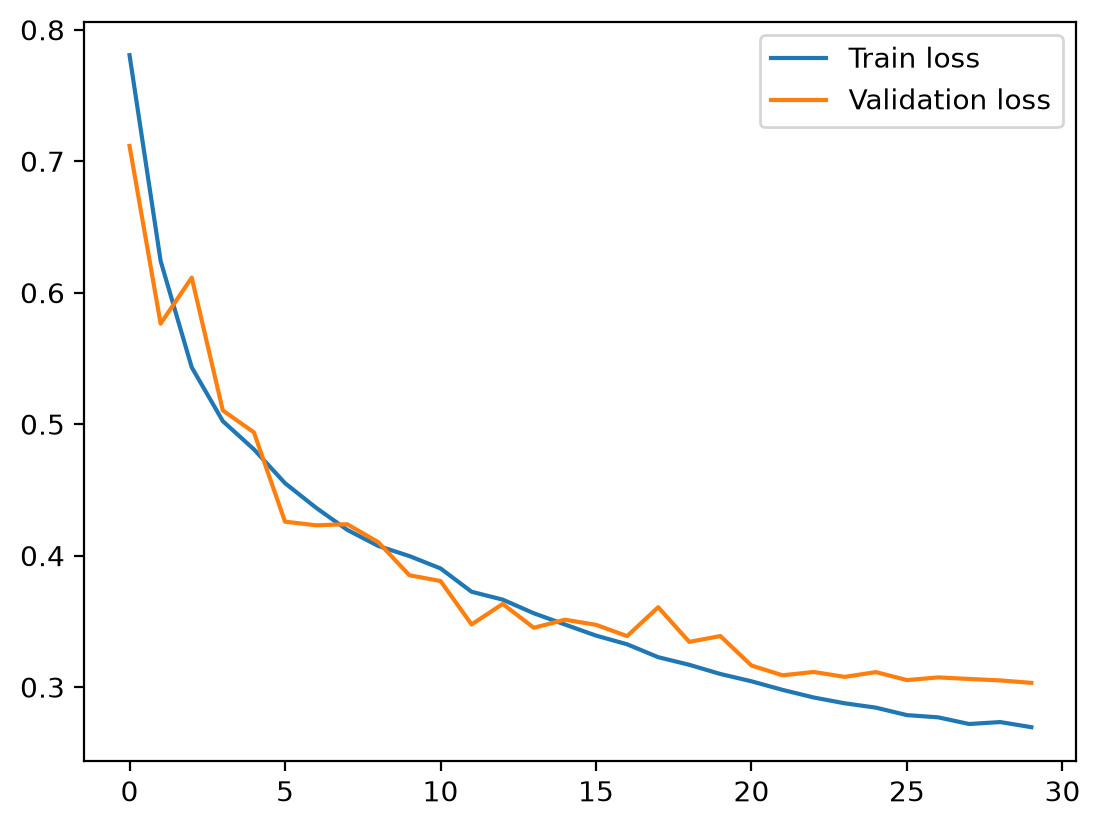

In [ ]:
# Loss curves
plt.figure(dpi=200)
plt.plot(np.arange(0, 30), train_loss, label='Train loss')
plt.plot(np.arange(0, 30), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# NOTE: this cell accumulates test-set metrics but never calls .compute() on them. The printed line reuses
# avg_train_loss (last training epoch) and epoch_miou / epoch_dice (last VALIDATION epoch), so the numbers
# below are validation results, not test results.
# Evaluate the trained model on the test set
test_sum_loss = 0
preds = []
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        miou_metric.update(test_predictions, test_labels)
        dice_metric.update(test_predictions, test_labels)
        preds.append(test_predictions)

avg_test_loss = test_sum_loss/len(test_loader)
print(    f'Test Loss: {avg_train_loss:.4f} | '
          f'mIoU: {epoch_miou:.4f} | '
          f'Dice (excl. BG): {epoch_dice:.4f}')

dice_metric.reset()
miou_metric.reset()    

Test Loss: 0.2695 | mIoU: 0.7379 | Dice (excl. BG): 0.5774


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-6.4943876..5.3967624].


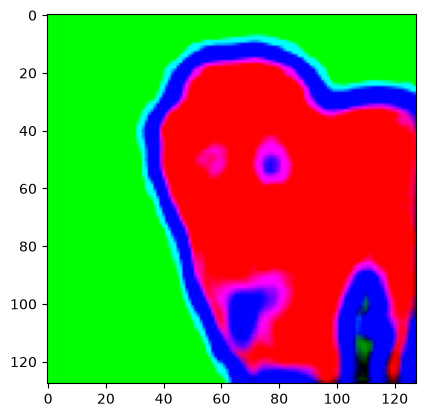

In [ ]:
# NOTE: raw logits shown as an RGB image (imshow clips the values, hence the warning); see the argmax view at the end for a readable mask.
img = preds[5][27].cpu().numpy().transpose(1, 2, 0) 
imgplot = plt.imshow(img)

## 7. Visualizing a prediction

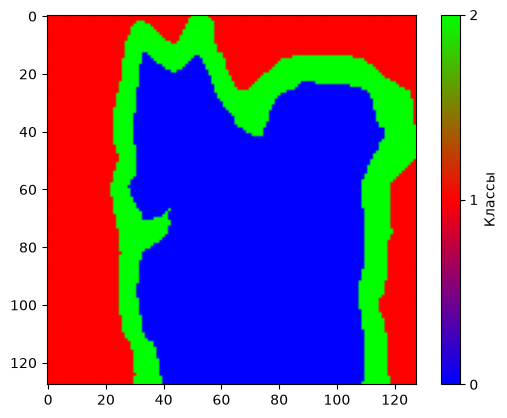

In [ ]:
# Predicted class map: argmax over the class dimension (0 = pet, 1 = background, 2 = border)
raw_logits = preds[10][31]

clean_mask = torch.argmax(raw_logits, dim=0).cpu().numpy()


plt.imshow(clean_mask, cmap='brg')
plt.clim(0, 2)
plt.colorbar(ticks=[0, 1, 2], label='Classes')
plt.show()



In [ ]:
# Predicted class ids
clean_mask

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(128, 128))

In [ ]:
# Raw logits of class 1 (background)
raw_logits[1]

tensor([[3.5389, 4.5273, 4.6013,  ..., 3.4846, 3.3666, 2.6009],
        [4.2776, 4.9053, 4.9774,  ..., 3.9118, 3.8191, 3.3462],
        [4.3577, 5.0027, 5.0238,  ..., 3.9074, 3.7254, 3.3852],
        ...,
        [3.4741, 3.8914, 3.8693,  ..., 2.1850, 2.4061, 2.2262],
        [3.4335, 3.9933, 3.9208,  ..., 2.2100, 2.4429, 2.1432],
        [2.4966, 3.2574, 3.2919,  ..., 1.9430, 2.1369, 1.7615]],
       device='cuda:0')